<a href="https://colab.research.google.com/github/CyberSnorlax/ETF-Markowitz-Portfolio-Optimization/blob/Alpha2/Alpha2_ROE_DE_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports and Setup**

In [12]:
# Connecting to folder through Google Drive
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/"LSTM-Only"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/LSTM-Only


In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import joblib
import datetime
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt

# File paths and date ranges
price_data_path = 'price_data.csv'
features_path = 'features_data.csv'
scaler_path = 'scaler.joblib'
sp500_index_path = 'sp500_index.csv'
X_train_scaled_path = 'X_train_scaled.joblib'
X_val_scaled_path = 'X_val_scaled.joblib'
X_test_scaled_path = 'X_test_scaled.joblib'
y_train_path = 'y_train.joblib'
y_val_path = 'y_val.joblib'
y_test_path = 'y_test.joblib'

# Define periods
train_start = '2018-01-01'
train_end = '2021-12-31'
val_start = '2021-12-31'
val_end = '2022-12-31'
test_start = '2022-12-31'
test_end = '2023-12-31'
data_start = '2017-01-01'

**Data Fetching Functions**

In [14]:
# Fetch S&P 500 tickers
def fetch_sp500_tickers():
    print("Fetching S&P500 tickers...")
    tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
    tickers = [t.replace('BRK.B', 'BRK-B').replace('BF.B', 'BF-B') for t in tickers]
    return tickers

# Fetch price data
def fetch_price_data(tickers):
    if os.path.exists(price_data_path):
        print("Loading existing price data...")
        return pd.read_csv(price_data_path, index_col='Date', parse_dates=True)
    print("Downloading price data...")
    data = yf.download(tickers, start=data_start, end=test_end, auto_adjust=True, threads=True)['Close']
    data = data.dropna(axis=1, thresh=int(0.9 * len(data)))
    data.to_csv(price_data_path)
    print(f"Saved price data for {len(data.columns)} tickers")
    return data

# Fetch S&P 500 index
def fetch_sp500_index():
    if os.path.exists(sp500_index_path):
        print("Loading S&P500 index data...")
        return pd.read_csv(sp500_index_path, index_col='Date', parse_dates=True)
    print("Downloading S&P500 index data...")
    sp500 = yf.download('^GSPC', start=data_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P500 index data")
    return sp500

# Get fundamentals
def get_fundamentals(ticker):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        roe = info.get('returnOnEquity', None)
        debt_to_equity = info.get('debtToEquity', None)
        return roe, debt_to_equity
    except Exception as e:
        print(f"Error fetching fundamentals for {ticker}: {e}")
        return None, None

**Feature Engineering Functions**

In [15]:
# Calculate technical indicators
def calculate_indicators(close):
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    sma200 = close.rolling(200).mean()
    sma_ratio = sma20 / sma50 - 1
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    macd_hist = macd - signal
    volatility = close.pct_change().rolling(30).std() * np.sqrt(252)
    std20 = close.rolling(20).std()
    bb_width = (sma20 + 2 * std20 - (sma20 - 2 * std20)) / sma20
    return pd.DataFrame({
        'sma_ratio': sma_ratio,
        'rsi': rsi,
        'macd_hist': macd_hist,
        'volatility': volatility,
        'bb_width': bb_width,
        'sma200': sma200
    })

# Calculate ARIMA features
def calculate_arima_features(close, periods=[5, 10, 21]):
    import warnings
    warnings.filterwarnings("ignore")
    arima_features = pd.DataFrame(index=close.index)
    log_close = np.log(close)
    log_returns = log_close.diff().dropna()
    try:
        model = ARIMA(log_returns, order=(1, 0, 1))
        model_fit = model.fit()
        for period in periods:
            forecast = model_fit.forecast(steps=period)
            cumulative_forecast = forecast.sum()
            current_log_price = log_close.iloc[-1]
            predicted_log_price = current_log_price + cumulative_forecast
            predicted_price = np.exp(predicted_log_price)
            current_price = close.iloc[-1]
            predicted_return = (predicted_price / current_price) - 1
            arima_features[f'arima_pred_{period}d'] = np.nan
            arima_features.iloc[-1, arima_features.columns.get_loc(f'arima_pred_{period}d')] = predicted_return
            arima_features[f'arima_pred_{period}d'] = arima_features[f'arima_pred_{period}d'].fillna(method='bfill')
        params = model_fit.params
        arima_features['arima_ar1'] = params.get('ar.L1', 0)
        arima_features['arima_ma1'] = params.get('ma.L1', 0)
        arima_features['arima_const'] = params.get('const', 0)
        arima_features['arima_aic'] = model_fit.aic
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252)
    except Exception as e:
        print(f"ARIMA model error: {e}")
        for period in periods:
            arima_features[f'arima_pred_{period}d'] = 0
        arima_features['arima_ar1'] = 0
        arima_features['arima_ma1'] = 0
        arima_features['arima_const'] = 0
        arima_features['arima_aic'] = 0
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252) if not log_returns.empty else 0
    return arima_features

# Prepare feature dataset
def prepare_data(price_data, sp500_index, tickers):
    features_list = []
    regime = (sp500_index.rolling(200).mean() > sp500_index).astype(int)
    for ticker in tickers:
        print(f"Processing {ticker}...")
        try:
            close = price_data[ticker].dropna()
            if len(close) < 252:
                print(f"Skipping {ticker}: insufficient data")
                continue
            tech_df = calculate_indicators(close)
            arima_df = calculate_arima_features(close)
            features_df = pd.concat([tech_df, arima_df], axis=1)
            features_df = features_df.loc[:, ~features_df.columns.duplicated()]
            roe, debt_to_equity = get_fundamentals(ticker)
            if roe is None or debt_to_equity is None:
                print(f"Skipping {ticker}: missing fundamentals")
                continue
            features_df['roe'] = roe
            features_df['debt_to_equity'] = debt_to_equity
            features_df['above_sma200'] = (close > features_df['sma200']).astype(int)
            features_df['fund_long'] = ((close > features_df['sma200']) & (roe > 0.20) & (debt_to_equity < 1)).astype(int)
            features_df['fund_short'] = ((close < features_df['sma200']) & (roe < 0.10) & (debt_to_equity > 2)).astype(int)
            features_df['ticker'] = ticker
            features_df['date'] = close.index
            features_df['future_price'] = close.shift(-21)
            features_df['fwd_return'] = (features_df['future_price'] / close) - 1
            feature_cols = list(features_df.columns.difference(['ticker', 'date', 'future_price', 'fwd_return']))
            features_df = features_df.dropna(subset=['fwd_return'] + feature_cols)
            if len(features_df) < 50:
                print(f"Skipping {ticker}: insufficient rows")
                continue
            features_df['label'] = pd.qcut(features_df['fwd_return'], q=[0, 0.25, 0.75, 1], labels=[-1, 0, 1], duplicates='drop').astype(int)
            features_df['regime'] = regime.reindex(features_df.index, method='ffill').fillna(0)
            features_list.append(features_df)
        except Exception as e:
            print(f"Error processing {ticker}: {e}")
    if not features_list:
        raise ValueError("No valid feature data.")
    all_features = pd.concat(features_list, ignore_index=True)
    all_features.to_csv(features_path, index=False)
    print(f"Saved features data")
    return all_features

**Data Fetching and Feature Preparation**

In [16]:
# Execute data fetching and feature preparation
tickers = fetch_sp500_tickers()
price_data = fetch_price_data(tickers)
sp500_index = fetch_sp500_index()
features_df = prepare_data(price_data, sp500_index, tickers)

Fetching S&P500 tickers...
Loading existing price data...
Loading S&P500 index data...
Processing MMM...
Processing AOS...
Processing ABT...
Skipping ABT: missing fundamentals
Processing ABBV...
Processing ACN...
Processing ADBE...
Processing AMD...
Processing AES...
Processing AFL...
Processing A...
Processing APD...
Processing ABNB...
Error processing ABNB: 'ABNB'
Processing AKAM...
Processing ALB...
Processing ARE...
Processing ALGN...
Processing ALLE...
Processing LNT...
Processing ALL...
Processing GOOGL...
Processing GOOG...
Processing MO...
Skipping MO: missing fundamentals
Processing AMZN...
Processing AMCR...
Processing AEE...
Processing AEP...
Processing AXP...
Processing AIG...
Processing AMT...
Processing AWK...
Processing AMP...
Processing AME...
Processing AMGN...
Processing APH...
Processing ADI...
Processing ANSS...
Processing AON...
Processing APA...
Processing APO...
Processing AAPL...
Processing AMAT...
Processing APTV...
Processing ACGL...
Processing ADM...
Processi

**LSTM Training**

In [17]:
# Train LSTM model
def train_lstm(features_df):
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                 'above_sma200', 'fund_long', 'fund_short', 'regime']
    arima_cols = [col for col in features_df.columns if col.startswith('arima_')]
    X_cols = base_cols + arima_cols
    print(f"Training LSTM with {len(X_cols)} features, including {len(arima_cols)} ARIMA features")
    features_df['date'] = pd.to_datetime(features_df['date'])
    train_df = features_df[(features_df['date'] >= train_start) & (features_df['date'] <= train_end)]
    val_df = features_df[(features_df['date'] > train_end) & (features_df['date'] <= val_end)]
    test_df = features_df[(features_df['date'] > val_end) & (features_df['date'] <= test_end)]
    X_train, y_train = train_df[X_cols], train_df['label']
    X_val, y_val = val_df[X_cols], val_df['label']
    X_test, y_test = test_df[X_cols], test_df['label']
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    joblib.dump(scaler, scaler_path)
    joblib.dump(X_train_scaled, X_train_scaled_path)
    joblib.dump(X_val_scaled, X_val_scaled_path)
    joblib.dump(X_test_scaled, X_test_scaled_path)
    joblib.dump(y_train, y_train_path)
    joblib.dump(y_val, y_val_path)
    joblib.dump(y_test, y_test_path)
    print("Saved scaled data and labels")
    sequence_length = 20
    def create_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i+seq_len)])
            ys.append(y.iloc[i+seq_len])
        return np.array(Xs), np.array(ys)
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, sequence_length)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, sequence_length)
    y_train_seq = pd.get_dummies(y_train_seq).values
    y_val_seq = pd.get_dummies(y_val_seq).values
    y_test_seq = pd.get_dummies(y_test_seq).values
    lstm = Sequential([
        LSTM(50, return_sequences=True, input_shape=(sequence_length, len(X_cols))),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    lstm.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_data=(X_val_seq, y_val_seq), verbose=1)
    lstm_val_acc = lstm.evaluate(X_val_seq, y_val_seq, verbose=0)[1]
    print(f"LSTM Validation Accuracy: {lstm_val_acc:.4f}")
    lstm.save('lstm_model.h5')
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

# Execute LSTM training
X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test = train_lstm(features_df)

Training LSTM with 19 features, including 8 ARIMA features
Saved scaled data and labels
Epoch 1/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 207s 19ms/step - accuracy: 0.5345 - loss: 0.9891 - val_accuracy: 0.3882 - val_loss: 1.3932
Epoch 2/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 204s 19ms/step - accuracy: 0.5564 - loss: 0.9401 - val_accuracy: 0.3831 - val_loss: 1.5917
Epoch 3/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 204s 19ms/step - accuracy: 0.5703 - loss: 0.9143 - val_accuracy: 0.3827 - val_loss: 1.5848
Epoch 4/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 204s 19ms/step - accuracy: 0.5812 - loss: 0.8951 - val_accuracy: 0.3769 - val_loss: 1.6932
Epoch 5/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 202s 19ms/step - accuracy: 0.5918 - loss: 0.8762 - val_accuracy: 0.3781 - val_loss: 1.6551
Epoch 6/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 200s 19ms/step - accuracy: 0.6010 - loss: 0.8602 - val_accuracy: 0.3730 - val_loss: 1.7568
Epoch 7/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 200s 19ms/step - accuracy: 0.6085 - loss: 0.8434 - val_acc

LSTM Validation Accuracy: 0.3827


**Prediction Aggregation**

In [18]:
# Aggregate LSTM predictions
def aggregate_predictions(features_df, scaler):
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                 'above_sma200', 'fund_long', 'fund_short', 'regime']
    arima_cols = [col for col in features_df.columns if col.startswith('arima_')]
    X_cols = base_cols + arima_cols
    print(f"Making predictions with {len(X_cols)} features")
    X_full = features_df[X_cols]
    X_full_scaled = scaler.transform(X_full)
    lstm = load_model('lstm_model.h5')
    seq_len = 20
    def create_sequences(X, seq_len):
        Xs = []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i+seq_len)])
        return np.array(Xs)
    X_full_seq = create_sequences(X_full_scaled, seq_len)
    lstm_preds_prob = lstm.predict(X_full_seq, verbose=0)
    lstm_preds = np.argmax(lstm_preds_prob, axis=1) - 1
    pred_df = features_df.iloc[seq_len:].copy()
    pred_df['lstm_pred'] = lstm_preds
    for period in [5, 10, 21]:
        col = f'arima_pred_{period}d'
        if col in pred_df.columns:
            pred_df[f'arima_{period}d_signal'] = np.where(
                pred_df[col] > 0.01, 1,
                np.where(pred_df[col] < -0.01, -1, 0)
            )
    pred_df.to_csv('model_predictions.csv', index=False)
    print("Saved model predictions")
    return pred_df

# Execute prediction aggregation
scaler = joblib.load(scaler_path)
pred_df = aggregate_predictions(features_df, scaler)

Making predictions with 19 features
Saved model predictions


**Portfolio Construction**

In [26]:
# Construct portfolio
def construct_portfolio(pred_df, test_start, test_end, n_long=10, n_short=10):
    print("Constructing portfolio...")

    # Convert dates to datetime objects
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df['year_month'] = pred_df['date'].dt.to_period('M')

    # Filter the dataframe for dates between test_start and test_end
    test_start = pd.to_datetime(test_start)
    test_end = pd.to_datetime(test_end)
    filtered_df = pred_df[(pred_df['date'] >= test_start) & (pred_df['date'] <= test_end)]

    print(f"Portfolio construction period: {test_start.strftime('%Y-%m-%d')} to {test_end.strftime('%Y-%m-%d')}")
    print(f"Number of records in test period: {len(filtered_df)}")

    portfolio_list = []

    for period, group in filtered_df.groupby('year_month'):
        group_long = group[(group['above_sma200'] == 1) & (group['roe'] > 0.20) & (group['debt_to_equity'] < 1)]
        group_short = group[(group['above_sma200'] == 0) & (group['roe'] < 0.10) & (group['debt_to_equity'] > 2)]

        group_long_sorted = group_long.sort_values('lstm_pred', ascending=False)
        group_short_sorted = group_short.sort_values('lstm_pred', ascending=True)

        if len(group_long_sorted) < n_long or len(group_short_sorted) < n_short:
            print(f"Period {period}: Not enough candidates.")
            continue

        long_stocks = group_long_sorted.head(n_long)[['ticker', 'date', 'lstm_pred']]
        long_stocks['position'] = 'long'

        short_stocks = group_short_sorted.head(n_short)[['ticker', 'date', 'lstm_pred']]
        short_stocks['position'] = 'short'

        print(f"\n{period} Long Positions:")
        print(long_stocks[['ticker', 'lstm_pred']])
        print(f"{period} Short Positions:")
        print(short_stocks[['ticker', 'lstm_pred']])

        month_portfolio = pd.concat([long_stocks, short_stocks])
        month_portfolio['year_month'] = period
        portfolio_list.append(month_portfolio)

    if not portfolio_list:
        raise ValueError("No valid portfolio selections within the specified date range.")

    portfolio_df = pd.concat(portfolio_list, ignore_index=True)
    portfolio_df.to_csv('portfolio_selections.csv', index=False)
    print("Saved portfolio selections")

    return portfolio_df

# Execute portfolio construction with test period parameters
portfolio_df = construct_portfolio(pred_df, test_start, test_end)

Constructing portfolio...
Portfolio construction period: 2022-12-31 to 2023-12-31
Number of records in test period: 106750

2023-01 Long Positions:
       ticker  lstm_pred
235067   ERIE          1
235063   ERIE          1
235062   ERIE          1
235060   ERIE          1
235061   ERIE          1
235059   ERIE          1
235058   ERIE          1
235057   ERIE          1
235056   ERIE          1
235068   ERIE          1
2023-01 Short Positions:
       ticker  lstm_pred
643172     WY         -1
640089   WELL         -1
640090   WELL         -1
640091   WELL         -1
633930    WBD         -1
629313    WBA         -1
629314    WBA         -1
629297    WBA         -1
629298    WBA         -1
629311    WBA         -1

2023-02 Long Positions:
       ticker  lstm_pred
424509   MPWR          1
424508   MPWR          1
424511   MPWR          1
424510   MPWR          1
424512   MPWR          1
424513   MPWR          1
424514   MPWR          1
424497   MPWR          1
64221    ANET          0
64

**Portfolio Backtesting**

Backtesting portfolio...

2023-01 Positions:
Long: ['ERIE']
Short: ['WY', 'WELL', 'WBD', 'WBA']
2023-01 Monthly Return: -0.1778

2023-02 Positions:
Long: ['MPWR', 'ANET']
Short: ['UDR', 'RVTY', 'PARA', 'NI', 'MDT']
2023-02 Monthly Return: 0.1539

2023-03 Positions:
Long: ['MPWR', 'ERIE']
Short: ['ALB', 'VTR']
2023-03 Monthly Return: 0.1248

2023-04 Positions:
Long: ['MPWR']
Short: ['ALB', 'UDR', 'TSN']
2023-04 Monthly Return: -0.0453

2023-05 Positions:
Long: ['MPWR', 'ANET']
Short: ['DIS', 'TSN']
2023-05 Monthly Return: 0.2124

2023-06 Positions:
Long: ['MPWR']
Short: ['WY', 'VTR', 'RVTY', 'REG']
2023-06 Monthly Return: -0.0009

2023-07 Positions:
Long: ['MPWR']
Short: ['ALB', 'TSN', 'O']
2023-07 Monthly Return: 0.0131

2023-08 Positions:
Long: ['MPWR', 'TPL', 'ERIE']
Short: ['ALB', 'ARE', 'DIS']
2023-08 Monthly Return: 0.2089

2023-09 Positions:
Long: ['TPL', 'MPWR']
Short: ['ALB']
2023-09 Monthly Return: 0.0719

2023-10 Positions:
Long: ['ANET']
Short: ['ALB']
2023-10 Monthly Return

[*********************100%***********************]  1 of 1 completed


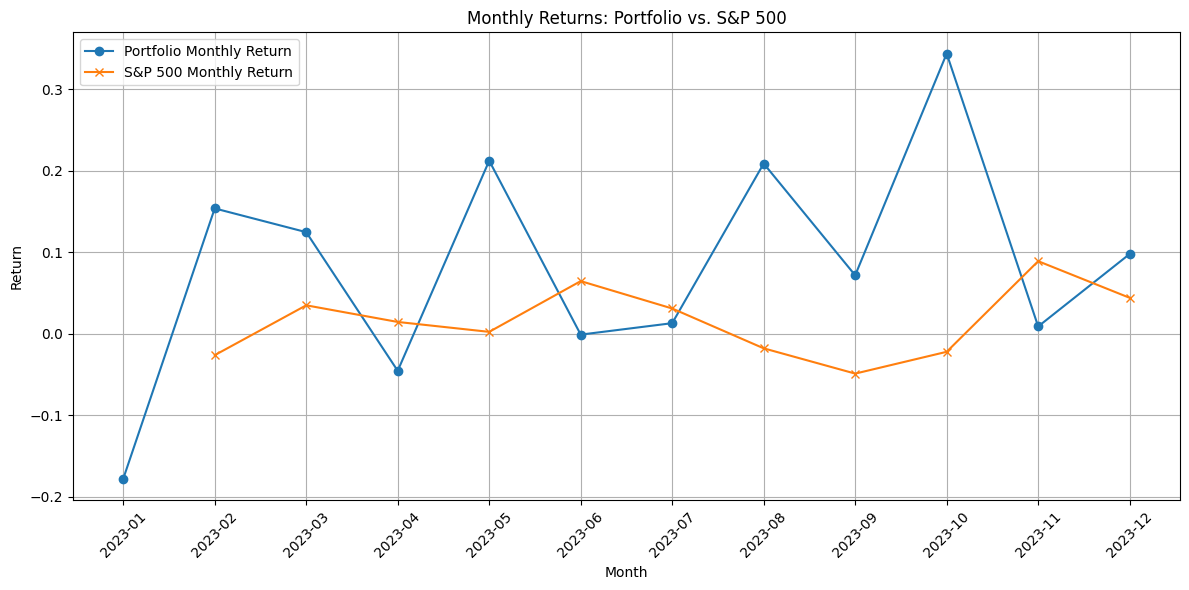

In [20]:
# Backtest portfolio
def backtest_portfolio(price_data, portfolio_df):
    print("Backtesting portfolio...")
    price_data_test = price_data.loc[test_start:test_end]
    portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
    portfolio_df = portfolio_df[(portfolio_df['date'] >= test_start) & (portfolio_df['date'] <= test_end)]
    portfolio_df['year_month'] = portfolio_df['date'].dt.to_period('M')
    daily_returns = price_data_test.pct_change().dropna()
    monthly_returns = []
    for period, group in portfolio_df.groupby('year_month'):
        month_start = group['date'].min()
        month_end = month_start + pd.offsets.MonthEnd(0)
        if month_end > pd.to_datetime(test_end):
            month_end = pd.to_datetime(test_end)
        month_ret = daily_returns.loc[month_start:month_end]
        if month_ret.empty:
            continue
        long_tickers = group[group['position'] == 'long']['ticker'].unique().tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].unique().tolist()
        print(f"\n{period} Positions:")
        print("Long:", long_tickers)
        print("Short:", short_tickers)
        long_returns = month_ret[long_tickers].mean(axis=1) if long_tickers else pd.Series()
        short_returns = month_ret[short_tickers].mean(axis=1) if short_tickers else pd.Series()
        if long_returns.empty or short_returns.empty:
            print(f"Skipping {period}: insufficient returns.")
            continue
        long_cum_return = (1 + long_returns).cumprod().iloc[-1] - 1
        short_cum_return = (1 + short_returns).cumprod().iloc[-1] - 1
        portfolio_return = (long_cum_return - short_cum_return)
        print(f"{period} Monthly Return: {portfolio_return:.4f}")
        monthly_returns.append({
            'year_month': str(period),
            'long_return': long_cum_return,
            'short_return': short_cum_return,
            'portfolio_return': portfolio_return
        })
    returns_df = pd.DataFrame(monthly_returns)
    returns_df.to_csv('portfolio_returns.csv', index=False)
    print("Saved portfolio returns")
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_monthly.index = sp500_monthly.index.to_period('M')
    plt.figure(figsize=(12,6))
    plt.plot(returns_df['year_month'], returns_df['portfolio_return'], marker='o', label='Portfolio Monthly Return')
    plt.plot(sp500_monthly.index.astype(str), sp500_monthly.values, marker='x', label='S&P 500 Monthly Return')
    plt.title('Monthly Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    return returns_df

# Execute backtesting
returns_df = backtest_portfolio(price_data, portfolio_df)

**Performance Evaluation**

[*********************100%***********************]  1 of 1 completed

Evaluating performance...
Saved performance metrics

Portfolio Performance Summary:
Total Return: 1.4123
Annualized Return: 1.4123
Annualized Volatility: 0.4781
Sharpe Ratio: 2.9121
Maximum Drawdown: -0.0453


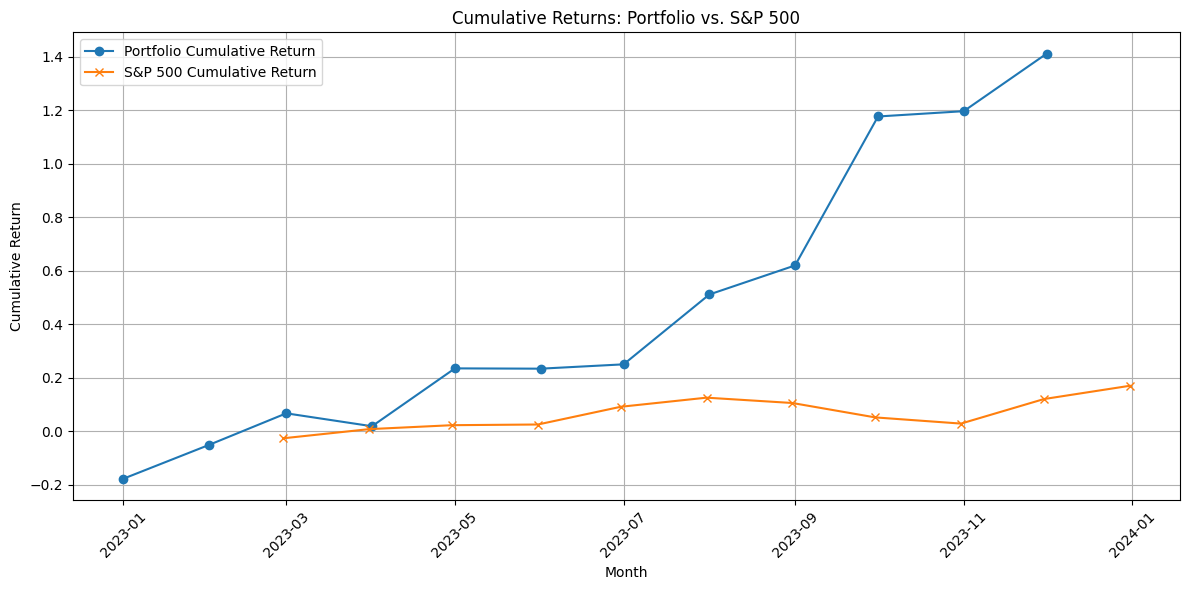

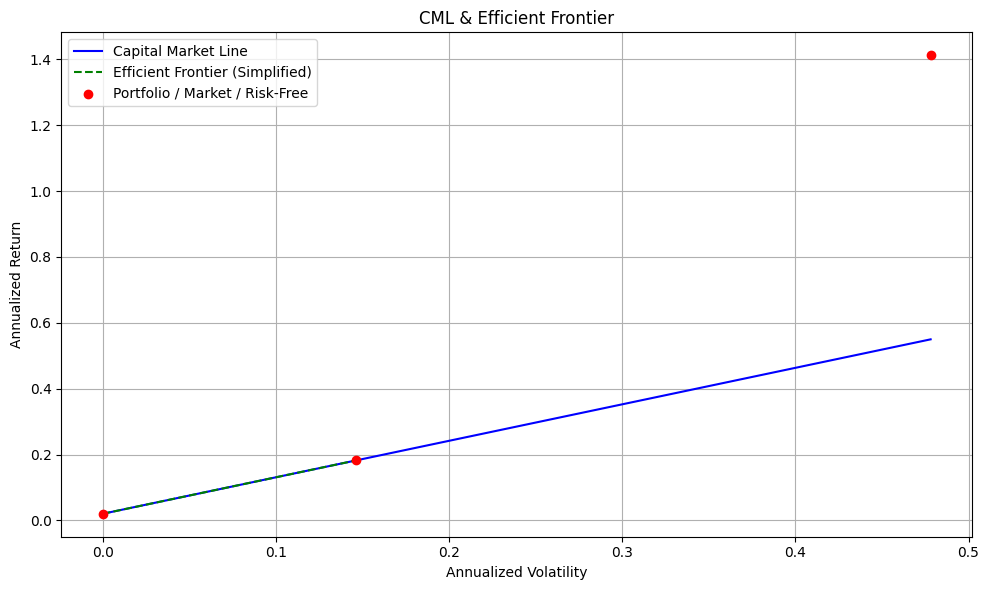

In [21]:
# Evaluate performance
def evaluate_performance(returns_df, risk_free_rate=0.02):
    print("Evaluating performance...")
    returns_df['year_month'] = pd.to_datetime(returns_df['year_month'])
    returns_df = returns_df.sort_values('year_month')
    returns_df['cumulative_return'] = (1 + returns_df['portfolio_return']).cumprod() - 1
    n_months = len(returns_df)
    total_return = returns_df['cumulative_return'].iloc[-1] if n_months > 0 else 0
    annualized_return = ((1 + total_return) ** (12 / n_months)) - 1 if n_months > 0 else 0
    monthly_vol = returns_df['portfolio_return'].std()
    annualized_vol = monthly_vol * np.sqrt(12) if monthly_vol is not None else 0
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol != 0 else 0
    cumulative = (1 + returns_df['portfolio_return']).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    performance_metrics = {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }
    perf_df = pd.DataFrame([performance_metrics])
    perf_df.to_csv('portfolio_performance.csv', index=False)
    print("Saved performance metrics")
    print("\nPortfolio Performance Summary:")
    for key, value in performance_metrics.items():
        print(f"{key}: {value:.4f}")
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    sp500_monthly_close = sp500.resample('ME').last()
    sp500_monthly_returns = sp500_monthly_close.pct_change().dropna()
    sp500_monthly_cum = (1 + sp500_monthly_returns).cumprod() - 1
    plt.figure(figsize=(12,6))
    plt.plot(returns_df['year_month'], returns_df['cumulative_return'], marker='o', label='Portfolio Cumulative Return')
    plt.plot(sp500_monthly_cum.index, sp500_monthly_cum.values, marker='x', label='S&P 500 Cumulative Return')
    plt.title('Cumulative Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Cumulative Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    market_return = float(sp500_monthly_returns.mean() * 12)
    market_vol = float(sp500_monthly_returns.std() * np.sqrt(12))
    cml_slope = (market_return - risk_free_rate) / market_vol if market_vol != 0 else 0
    cml_vols = np.linspace(0, max(annualized_vol, market_vol), 100)
    cml_returns = risk_free_rate + cml_slope * cml_vols
    eff_vols = np.linspace(0, market_vol, 100)
    eff_returns = risk_free_rate + (market_return - risk_free_rate) * (eff_vols / market_vol)
    plt.figure(figsize=(10,6))
    plt.plot(cml_vols, cml_returns, label='Capital Market Line', color='blue')
    plt.plot(eff_vols, eff_returns, label='Efficient Frontier (Simplified)', color='green', linestyle='--')
    plt.scatter([annualized_vol, market_vol, 0], [annualized_return, market_return, risk_free_rate],
                color='red', zorder=5, label='Portfolio / Market / Risk-Free')
    plt.title('CML & Efficient Frontier')
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    return returns_df, performance_metrics

# Execute performance evaluation
returns_df, performance_metrics = evaluate_performance(returns_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Portfolio Performance Summary:
Total Return: 0.2473
Annualized Return: 0.2506
Annualized Volatility: 0.1311
Sharpe Ratio: 1.7591
Maximum Drawdown: -0.1233


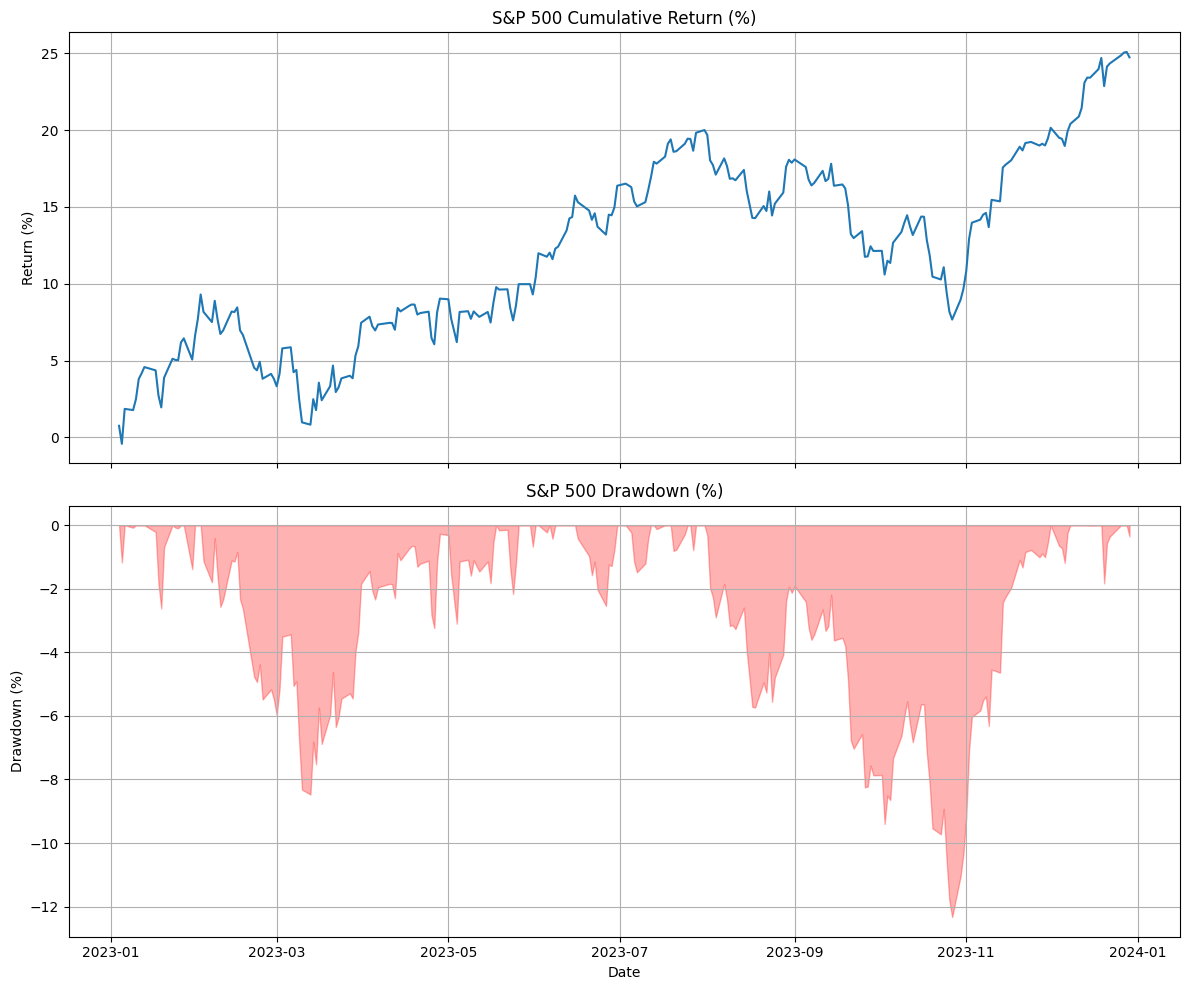

In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

def get_portfolio_summary(start_date, end_date, ticker='^GSPC'):
    """
    Get S&P 500 portfolio summary for a specific time period

    Parameters:
    start_date (str): Start date in 'YYYY-MM-DD' format
    end_date (str): End date in 'YYYY-MM-DD' format
    ticker (str): Yahoo Finance ticker symbol, default is S&P 500

    Returns:
    dict: Portfolio performance metrics
    """
    # Download S&P 500 data
    sp500 = yf.download(ticker, start=start_date, end=end_date)

    # Check available columns and use Close if Adj Close is not available
    price_col = 'Close'  # Use Close instead of Adj Close

    # Calculate daily returns
    sp500['Daily Return'] = sp500[price_col].pct_change()

    # Drop NaN values
    sp500 = sp500.dropna()

    # Calculate metrics
    daily_returns = sp500['Daily Return']
    cumulative_return = (1 + daily_returns).prod() - 1
    trading_days = 252  # Standard assumption for trading days in a year

    # Annualized return
    total_days = len(sp500)
    years = total_days / trading_days
    annualized_return = (1 + cumulative_return) ** (1 / years) - 1

    # Annualized volatility
    annualized_volatility = daily_returns.std() * np.sqrt(trading_days)

    # Sharpe ratio (assuming risk-free rate of 0.02)
    risk_free_rate = 0.02
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    # Maximum drawdown
    cumulative_returns = (1 + daily_returns).cumprod() - 1
    rolling_max = cumulative_returns.cummax()
    drawdown = cumulative_returns - rolling_max
    max_drawdown = drawdown.min()

    # Create dictionary of results
    results = {
        'Total Return': cumulative_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

    return results

def print_portfolio_summary(metrics):
    """
    Print formatted portfolio summary

    Parameters:
    metrics (dict): Portfolio performance metrics
    """
    print("Portfolio Performance Summary:")
    print(f"Total Return: {metrics['Total Return']:.4f}")
    print(f"Annualized Return: {metrics['Annualized Return']:.4f}")
    print(f"Annualized Volatility: {metrics['Annualized Volatility']:.4f}")
    print(f"Sharpe Ratio: {metrics['Sharpe Ratio']:.4f}")
    print(f"Maximum Drawdown: {metrics['Maximum Drawdown']:.4f}")

def plot_performance(start_date, end_date, ticker='^GSPC'):
    """
    Plot S&P 500 performance and drawdown for the given period

    Parameters:
    start_date (str): Start date in 'YYYY-MM-DD' format
    end_date (str): End date in 'YYYY-MM-DD' format
    ticker (str): Yahoo Finance ticker symbol, default is S&P 500
    """
    sp500 = yf.download(ticker, start=start_date, end=end_date)

    # Use Close instead of Adj Close
    price_col = 'Close'

    sp500['Daily Return'] = sp500[price_col].pct_change()
    sp500 = sp500.dropna()

    # Calculate cumulative returns
    sp500['Cumulative Return'] = (1 + sp500['Daily Return']).cumprod() - 1

    # Calculate drawdown
    sp500['Rolling Max'] = sp500['Cumulative Return'].cummax()
    sp500['Drawdown'] = sp500['Cumulative Return'] - sp500['Rolling Max']

    # Create plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot cumulative return
    ax1.plot(sp500.index, sp500['Cumulative Return'] * 100)
    ax1.set_title('S&P 500 Cumulative Return (%)')
    ax1.set_ylabel('Return (%)')
    ax1.grid(True)

    # Plot drawdown
    ax2.fill_between(sp500.index, sp500['Drawdown'] * 100, 0, color='red', alpha=0.3)
    ax2.set_title('S&P 500 Drawdown (%)')
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_xlabel('Date')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Define time period
    start_date = '2022-12-31'
    end_date = '2023-12-31' # You can use datetime.today().strftime('%Y-%m-%d') for today

    # Get and print portfolio summary
    metrics = get_portfolio_summary(start_date, end_date)
    print_portfolio_summary(metrics)

    # Plot performance
    plot_performance(start_date, end_date)